# Data Collection and preprocessing

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [71]:
!pip install --upgrade tensorflow keras

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 585.9/585.9 MB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 440.7/440.7 KB 39.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.4/302.4 KB 28.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.8/77.8 KB 9.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 76.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 101.2 MB/s eta 0:00:00
  Attempting uninstall: wrapt
    Found existing installation: wrapt 1.15.0
    Uninstalling wrapt-1.15.0:
      Successfully uninstalled wrapt-1.15.0
  Attempting uninstall: tensorflow-estimator
    Found existing installation: tensorflow-estimator 2.11.0
    Uninstalling tensorflow-estimator-2.11.0:
      Successfully uninstalled tensorflow-estimator-2.11.0
  Attempting uninstall: tensorboard-data-server
    Found

In [72]:
import tensorflow as tf
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt 
from tensorflow.keras.preprocessing.image import img_to_array

In [3]:
IMAGE_SIZE = 256
BATCH_SIZE = 32
CHANNELS = 3
EPOCHS = 50

In [4]:
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "/content/drive/MyDrive/Potato disease classification/Training/PlantVillage",
    shuffle=True,
    image_size = (IMAGE_SIZE,IMAGE_SIZE),
    batch_size = BATCH_SIZE
    )

Found 2162 files belonging to 3 classes.


In [5]:
class_names = dataset.class_names
class_names 
#folder names are class names

['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']

In [6]:
len(dataset) # because element in the dataset is a batch of 32 images 

68

In [7]:
68*32 # this is actual length beacuse each element is 32 batch

2176

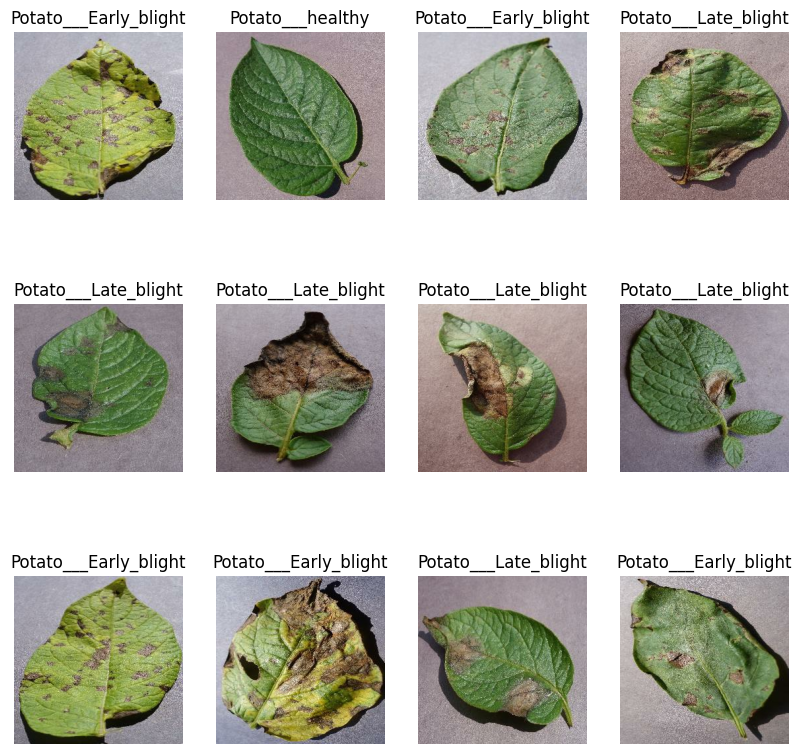

In [8]:
plt.figure(figsize=(10,10))
for image_batch, label_batch in dataset.take(1):
    for i in range(12):
        ax = plt.subplot(3,4,i+1)
        plt.imshow(image_batch[i].numpy().astype("uint8"))
        plt.title(class_names[label_batch[i]])
        plt.axis("off") #this will remove the axis 

In [9]:
train_size = 0.8
len(dataset) * train_size

54.400000000000006

In [10]:
train_ds = dataset.take(54)
len(train_ds)

54

In [11]:
test_ds = dataset.skip(54)
len(test_ds)

14

In [12]:
val_size = 0.1
len(dataset)*val_size

6.800000000000001

In [13]:
val_ds = dataset.take(6)
len(val_ds)

6

In [14]:
test_ds = test_ds.skip(6)
len(test_ds)

8

In [15]:
def get_dataset_partitions_tf(ds, train_split=0.8, val_split=0.1, test_split=0.1, shuffle=True, shuffle_size=10000):
    
    ds_size = len(ds)
    
    if shuffle:
        ds = ds.shuffle(shuffle_size, seed=12)
    
    train_size = int(train_split*ds_size)
    val_size = int(val_split*ds_size)
    test_size = int(test_split*ds_size)
    
    train_ds = ds.take(train_size)
    val_ds = ds.skip(train_size).take(val_size)
    test_ds = ds.skip(train_size).skip(val_size).take(test_size)
    
    return train_ds, val_ds, test_ds


In [16]:
train_ds, val_ds, test_ds = get_dataset_partitions_tf(dataset)

In [17]:
len(train_ds)

54

In [18]:
len(val_ds)

6

In [19]:
len(test_ds)

6

In [20]:
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

In [21]:
resize_and_rescale = tf.keras.Sequential([
    layers.experimental.preprocessing.Resizing(IMAGE_SIZE, IMAGE_SIZE),
    layers.experimental.preprocessing.Rescaling(1.0/255)
])

In [22]:
data_augmentation = tf.keras.Sequential([
    layers.experimental.preprocessing.RandomFlip("horizontal_and_vertical"),
    layers.experimental.preprocessing.RandomRotation(0.2),
])

# Model Building


In [23]:
input_shape = (BATCH_SIZE, IMAGE_SIZE, IMAGE_SIZE, CHANNELS)
n_classes = 3

model = models.Sequential([
    resize_and_rescale,
    data_augmentation,
    layers.Conv2D(32, (3,3), activation='relu', input_shape = input_shape),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu', input_shape = input_shape),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu', input_shape = input_shape),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu', input_shape = input_shape),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu', input_shape = input_shape),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu', input_shape = input_shape),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(n_classes, activation='softmax'),  
])

model.build(input_shape = input_shape)

In [24]:
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential (Sequential)     (32, 256, 256, 3)         0         
                                                                 
 sequential_1 (Sequential)   (None, 256, 256, 3)       0         
                                                                 
 conv2d (Conv2D)             (None, 254, 254, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 127, 127, 32)     0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 125, 125, 64)      18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 62, 62, 64)       0         
 2D)                                                  

In [25]:
model.compile(
    optimizer='adam',
    loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)


In [26]:
import tensorflow as tf
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))


Num GPUs Available:  1


In [27]:
history = model.fit(
train_ds,
epochs=EPOCHS,
batch_size=BATCH_SIZE,
verbose=1,
validation_data=val_ds)

Epoch 1/50


54/54 [==============================] - 404s 200ms/step - loss: 0.9195 - accuracy: 0.5006 - val_loss: 0.7549 - val_accuracy: 0.5833
Epoch 2/50
54/54 [==============================] - 6s 116ms/step - loss: 0.7784 - accuracy: 0.6377 - val_loss: 0.6271 - val_accuracy: 0.7812
Epoch 3/50
54/54 [==============================] - 6s 116ms/step - loss: 0.5634 - accuracy: 0.7616 - val_loss: 0.5207 - val_accuracy: 0.8073
Epoch 4/50
54/54 [==============================] - 6s 118ms/step - loss: 0.3857 - accuracy: 0.8484 - val_loss: 0.3359 - val_accuracy: 0.8698
Epoch 5/50
54/54 [==============================] - 7s 128ms/step - loss: 0.3006 - accuracy: 0.8791 - val_loss: 0.3848 - val_accuracy: 0.8542
Epoch 6/50
54/54 [==============================] - 6s 119ms/step - loss: 0.2755 - accuracy: 0.8900 - val_loss: 0.2877 - val_accuracy: 0.8750
Epoch 7/50
54/54 [==============================] - 6s 110ms/step - loss: 0.2123 - accuracy: 0.9271 - val_loss: 0.4072 - val_accuracy: 0.8594
Epoch 8/50
54/5

In [28]:
scores = model.evaluate(test_ds)

6/6 [==============================] - 4s 28ms/step - loss: 0.3104 - accuracy: 0.9167


In [29]:
scores

[0.31037962436676025, 0.9166666865348816]

In [30]:
history

In [31]:
len(history.history['accuracy'])

50

In [32]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

In [39]:
import plotly.graph_objs as go

# Create x and y data for first line plot
x1 = tuple(range(EPOCHS))
y1 = acc

# Create x and y data for second line plot
x2 = tuple(range(EPOCHS))
y2 = val_acc

# Create a single plot object
fig = go.Figure()

# Add the first line trace to the plot
fig.add_trace(go.Scatter(x=x1, y=y1, mode='lines', name='Training Accuracy'))

# Add the second line trace to the plot
fig.add_trace(go.Scatter(x=x2, y=y2, mode='lines', name='Validation Accuracy'))

# Update the plot layout
fig.update_layout(title='Training and Validation Accuracy', xaxis_title='EPOCHS', yaxis_title='Accuracy')

# Show the plot
fig.show()


In [40]:
import plotly.graph_objs as go

# Create x and y data for first line plot
x1 = tuple(range(EPOCHS))
y1 = loss

# Create x and y data for second line plot
x2 = tuple(range(EPOCHS))
y2 = val_loss

# Create a single plot object
fig = go.Figure()

# Add the first line trace to the plot
fig.add_trace(go.Scatter(x=x1, y=y1, mode='lines', name='Training Loss'))

# Add the second line trace to the plot
fig.add_trace(go.Scatter(x=x2, y=y2, mode='lines', name='Validation Loss'))

# Update the plot layout
fig.update_layout(title='Training and Validation Loss', xaxis_title='EPOCHS', yaxis_title='Loss')

# Show the plot
fig.show()

first image to predict
actual label: Potato___Early_blight
1/1 [==============================] - 0s 31ms/step
predicted label: Potato___Early_blight


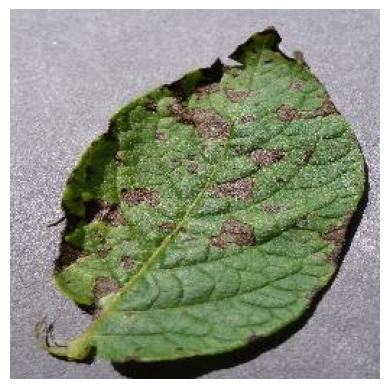

In [51]:
import numpy as np
for images_batch, labels_batch in test_ds.take(1):
  first_image = images_batch[0].numpy().astype('uint8') # this will print the first image 
  first_label = labels_batch[0].numpy()

  print("first image to predict")
  plt.imshow(first_image)
  plt.axis("off") # this will remove the axis 
  print("actual label:", class_names[first_label])

  batch_prediction = model.predict(images_batch)
  print("predicted label:", class_names[np.argmax(batch_prediction[0])])

In [74]:
def predict(model, img):
    img_array = tf.keras.preprocessing.image.img_to_array(images[i].numpy())
    img_array = tf.expand_dims(img_array, 0)

    predictions = model.predict(img_array)

    predicted_class = class_names[np.argmax(predictions[0])]
    confidence = round(100 * (np.max(predictions[0])), 2)
    return predicted_class, confidence

In [90]:
plt.figure(figsize=(15, 15))
for images, labels in test_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        
        predicted_class, confidence = predict(model, images[i].numpy())
        actual_class = class_names[labels[i]] 
        
        plt.title(f"Actual: {actual_class},\n Predicted: {predicted_class}.\n Confidence: {confidence}%")
        
        plt.axis("off")

Output hidden; open in https://colab.research.google.com to view.

In [94]:
import os
model_version=max([int(i) for i in os.listdir("/content/drive/MyDrive/Potato disease classification/Training/Model") + [0]])+1
model.save(f"/content/drive/MyDrive/Potato disease classification/Training/Model/{model_version}")